LSTMs solve the vanishing gradient problem

Input Gate, Forget Gate and Output Gate
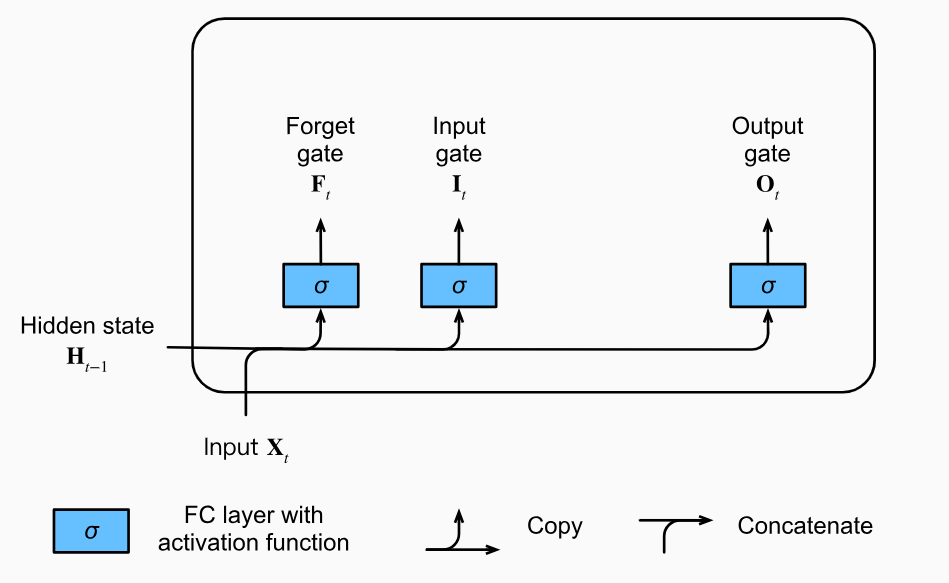

1. Gates ar time step t are defined as follows

It = sigmoid(Xt @ Wxi + Ht-1 @ Whi + bi) --- Input Gate (Determines if current input should impact memery cell)
Ft = sigmoid(Xt @ Wxf + Ht-1 @ Whf + bf) --- Forget Gate (Determines if memory cell value should be kept or flushed)
Ot = sigmoid(Xt @ Wxo + Ht-1 @ Who + bo) --- Output Gate (Determines if memory cell should influence output at current time step)

Xt = n x d matrix
Ht-1 = n x h matrix
Wxi, Wxf, Wxo = d x h matrix
Whi, Whf, Who = h x h matrix
bi, bf, bo = h vector

2. Candidate memory cell value is first calculated
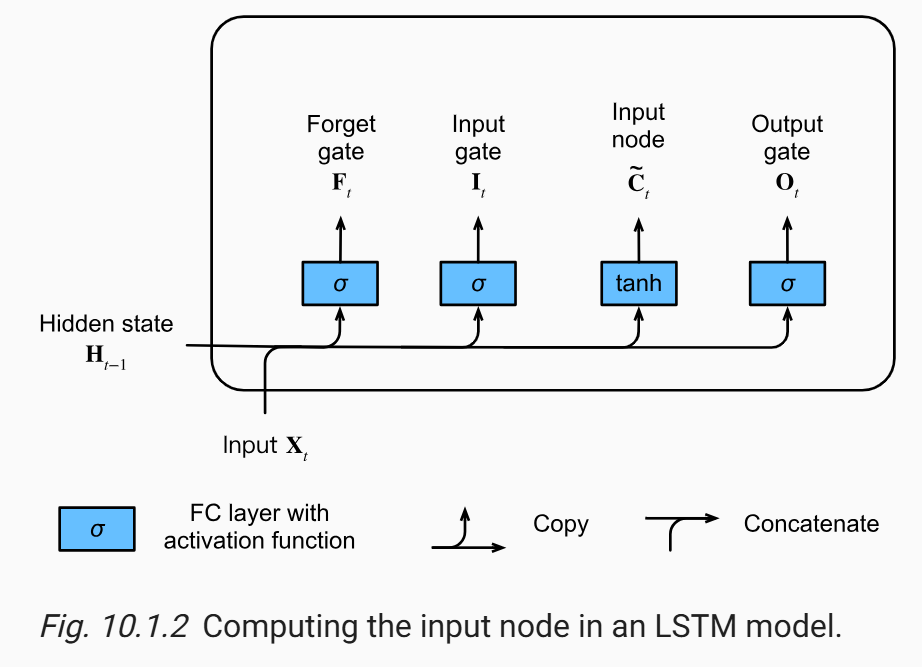

C~t = tanh(Xt @ Wxc + Ht-1 @ Whc + bc)

Wxc = d x h matrix
Whc = h x h matrix
bc = h vector

3. Memory Cell Value is calculated using input and forget gates

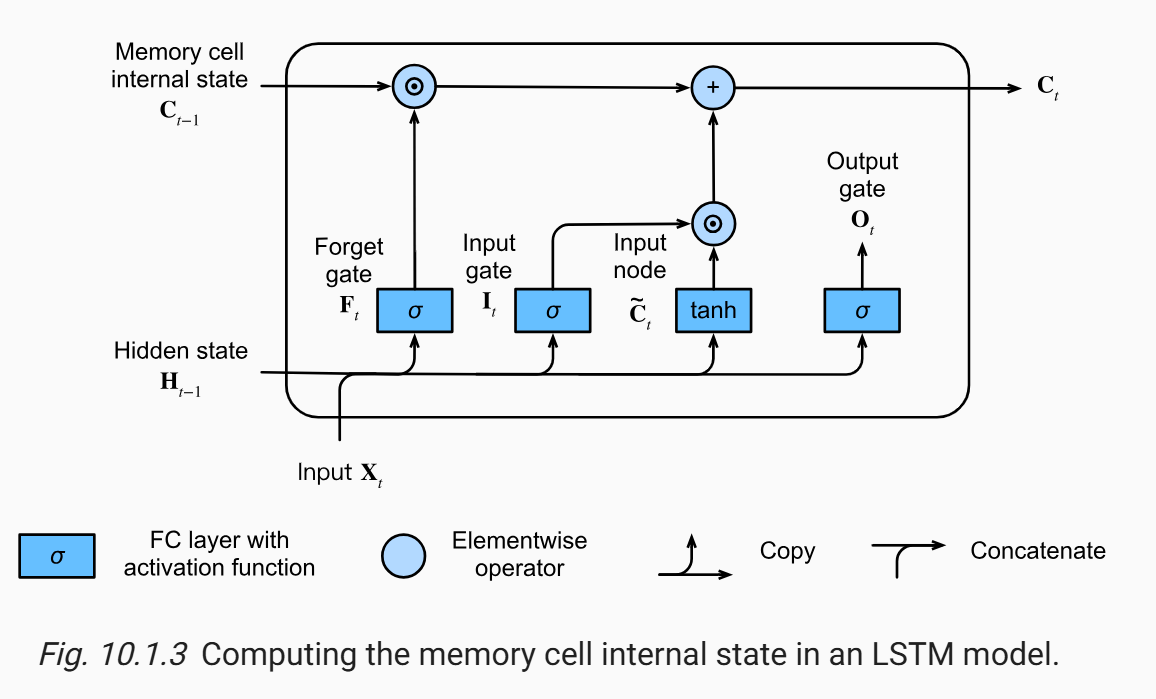

ct = Ft * ct-1 + It * c~t

4. Hidden state Ht is calculated

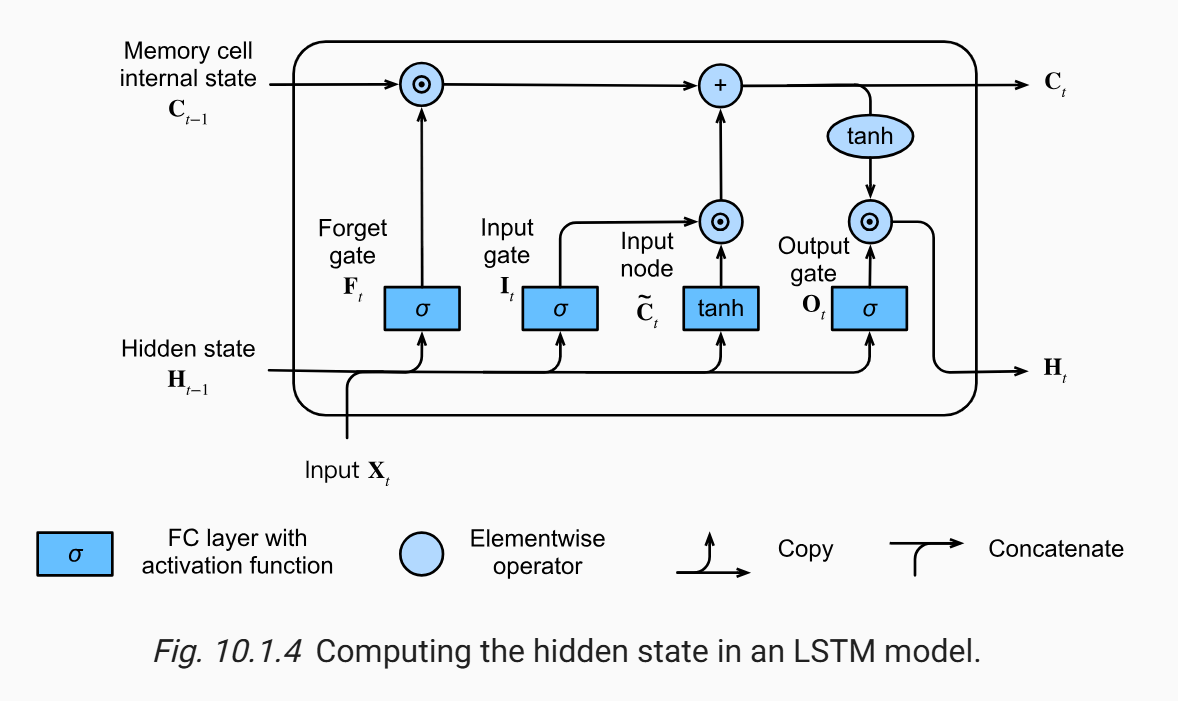

Ht = Ot * tanh(Ct)


In [1]:
import torch
from torch import nn
from d2l import torch as d2l

In [8]:
class LSTMScratch(d2l.Module):
    def __init__(self, num_inputs, num_hiddens, sigma=0.01):
        super().__init__()
        self.save_hyperparameters()

        init_weight = lambda *shape: nn.Parameter(torch.randn(*shape) * sigma)
        triple = lambda: (init_weight(num_inputs, num_hiddens),
            init_weight(num_hiddens, num_hiddens),
            nn.Parameter(torch.zeros(num_hiddens))
        )

        self.W_xi, self.W_hi, self.b_i = triple() #Input gate params
        self.W_xf, self.W_hf, self.b_f = triple() #Forget gate params
        self.W_xo, self.W_ho, self.b_o = triple() #Output gate params
        self.W_xc, self.W_hc, self.b_c = triple() #memory cell weights

    def forward(self, inputs, H_C=None):
        if H_C is None:
            H = torch.zeros((inputs.shape[1], self.num_hiddens))
            C = torch.zeros((inputs.shape[1], self.num_hiddens))
        else:
            H, C = H_C

        outputs = []
        for X in inputs:
            I = torch.sigmoid(torch.matmul(X, self.W_xi) + torch.matmul(H, self.W_hi) + self.b_i)
            F = torch.sigmoid(torch.matmul(X, self.W_xf) + torch.matmul(H, self.W_hf) + self.b_f)
            O = torch.sigmoid(torch.matmul(X, self.W_xo) + torch.matmul(H, self.W_ho) + self.b_o)
            C_tilde = torch.tanh(torch.matmul(X, self.W_xc) + torch.matmul(H, self.W_hc) + self.b_c)

            C = C * F + C_tilde * I
            H = O * torch.tanh(C)
            outputs.append(H)
        return outputs, (H, C)

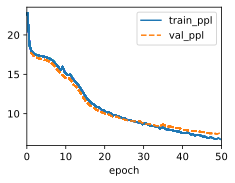

In [9]:
#Training model
data = d2l.TimeMachine(batch_size=1024, num_steps=32)
lstm = LSTMScratch(num_inputs=len(data.vocab), num_hiddens=32)
model = d2l.RNNLMScratch(lstm, vocab_size=len(data.vocab), lr=4)
trainer = d2l.Trainer(max_epochs=50, gradient_clip_val=1, num_gpus=1)
trainer.fit(model, data)

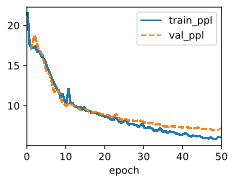

In [10]:
# Concise Implementation
class LSTM(d2l.RNN):
    def __init__(self, num_inputs, num_hiddens):
        d2l.Module.__init__(self)
        self.save_hyperparameters()
        self.rnn = nn.LSTM(num_inputs, num_hiddens)

    def forward(self, inputs, H_C=None):
        return self.rnn(inputs, H_C)
    
lstm = LSTM(num_inputs=len(data.vocab), num_hiddens=32)
model = d2l.RNNLM(lstm, vocab_size=len(data.vocab), lr=4)
trainer.fit(model, data)

In [11]:
model.predict('it has', 20, data.vocab)

'it has in the travell the '